In [4]:
!pip install pandas numpy matplotlib yfinance

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [6]:
# Advanced LBO Model – Apple Inc.

##This project builds a private equity-style leveraged buyout model including transaction structure, operating projections, capital structure, and return analysis.

In [7]:
ticker = yf.Ticker("AAPL")
financials = ticker.financials

revenue = float(financials.loc["Total Revenue"].iloc[0]) / 1e9 if "Total Revenue" in financials.index else 400
ebitda_margin = 0.30

print("Base Revenue:", revenue)

Base Revenue: 416.161


In [8]:
# Entry assumptions
entry_multiple = 12
ebitda_entry = revenue * ebitda_margin

purchase_price = ebitda_entry * entry_multiple

# Capital structure
senior_debt_percent = 0.5
mezz_debt_percent = 0.15
equity_percent = 0.35

# Debt amounts
senior_debt = purchase_price * senior_debt_percent
mezz_debt = purchase_price * mezz_debt_percent
equity = purchase_price * equity_percent

# Rates
senior_interest = 0.06
mezz_interest = 0.10

# Fees
transaction_fee_percent = 0.02
fees = purchase_price * transaction_fee_percent

In [9]:
sources_uses = pd.DataFrame({
    "Sources": [senior_debt, mezz_debt, equity],
    "Uses": [purchase_price, fees, 0]
}, index=["Senior Debt", "Mezz Debt", "Equity"])

sources_uses

,Sources,Uses
Senior Debt,749.08980,1498.179600
Mezz Debt,224.72694,29.963592
Equity,524.36286,0.000000


In [10]:
holding_period = 5
revenue_growth = 0.06
capex_percent = 0.04
wc_percent = 0.015
exit_multiple = 14

In [11]:
years = []
current_revenue = revenue
senior = senior_debt
mezz = mezz_debt

for year in range(1, holding_period + 1):

    current_revenue *= (1 + revenue_growth)
    ebitda = current_revenue * ebitda_margin

    capex = current_revenue * capex_percent
    wc = current_revenue * wc_percent

    interest_senior = senior * senior_interest
    interest_mezz = mezz * mezz_interest

    fcf = ebitda - capex - wc - interest_senior - interest_mezz

    paydown = max(fcf * 0.6, 0)
    senior -= min(paydown, senior)

    years.append({
        "Year": year,
        "Revenue": round(current_revenue,2),
        "EBITDA": round(ebitda,2),
        "FCF": round(fcf,2),
        "Senior Debt": round(senior,2),
        "Mezz Debt": round(mezz,2)
    })

df = pd.DataFrame(years)
df

,Year,Revenue,EBITDA,FCF,Senior Debt,Mezz Debt
0,1,441.13,132.34,40.66,724.69,224.73
1,2,467.60,140.28,48.61,695.53,224.73
2,3,495.65,148.70,57.23,661.19,224.73
3,4,525.39,157.62,66.58,621.25,224.73
4,5,556.92,167.08,76.70,575.23,224.73


In [12]:
final_ebitda = df.iloc[-1]["EBITDA"]
exit_value = final_ebitda * exit_multiple

remaining_debt = df.iloc[-1]["Senior Debt"] + df.iloc[-1]["Mezz Debt"]
equity_exit = exit_value - remaining_debt

irr = (equity_exit / equity) ** (1/holding_period) - 1
moic = equity_exit / equity

print("Exit Value:", round(exit_value,2))
print("Equity Exit:", round(equity_exit,2))
print("IRR:", round(irr*100,2), "%")
print("MOIC:", round(moic,2), "x")

Exit Value: 2339.12
Equity Exit: 1539.16
IRR: 24.03 %
MOIC: 2.94 x


In [13]:
print("Entry Multiple:", entry_multiple)
print("Exit Multiple:", exit_multiple)

if exit_multiple > entry_multiple:
    print("Value creation driven partly by multiple expansion")
elif exit_multiple < entry_multiple:
    print("Value creation dependent on operational improvement")
else:
    print("No multiple expansion — returns driven by growth and deleveraging")

Entry Multiple: 12
Exit Multiple: 14
Value creation driven partly by multiple expansion


In [14]:
ebitda_cagr = ((df.iloc[-1]["EBITDA"] / df.iloc[0]["EBITDA"])**(1/holding_period))-1
debt_initial = senior_debt + mezz_debt
debt_final = df.iloc[-1]["Senior Debt"] + df.iloc[-1]["Mezz Debt"]

debt_paydown = (debt_initial - debt_final)/debt_initial
cash_conversion = df["FCF"].mean()/df["EBITDA"].mean()

print("EBITDA CAGR:", round(ebitda_cagr*100,2), "%")
print("Debt Paydown:", round(debt_paydown*100,2), "%")
print("Cash Conversion:", round(cash_conversion,2))

EBITDA CAGR: 4.77 %
Debt Paydown: 17.85 %
Cash Conversion: 0.39


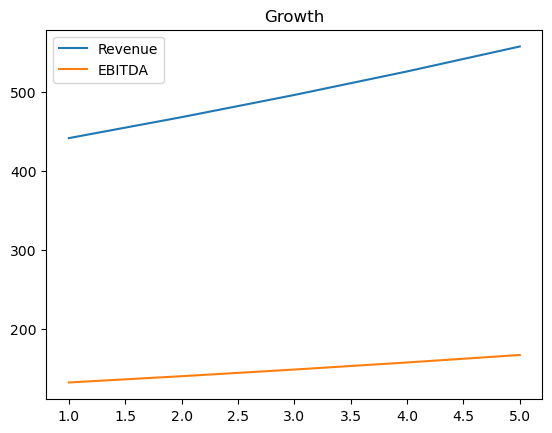

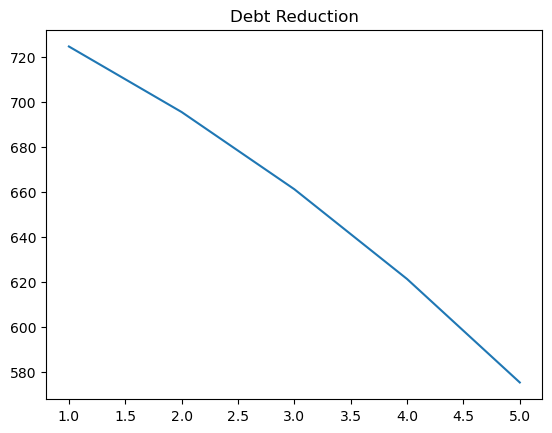

In [17]:
import matplotlib.pyplot as plt

# Revenue Graph
plt.figure()
plt.plot(df["Year"], df["Revenue"], label="Revenue")
plt.plot(df["Year"], df["EBITDA"], label="EBITDA")

plt.legend()
plt.title("Growth")

plt.savefig("/Users/nishantpandya/Downloads/revenue_ebitda_growth.png", dpi=300)
plt.show()


# Debt Graph
plt.figure()
plt.plot(df["Year"], df["Senior Debt"], label="Senior Debt")

plt.title("Debt Reduction")

plt.savefig("/Users/nishantpandya/Downloads/debt_reduction.png", dpi=300)
plt.show()

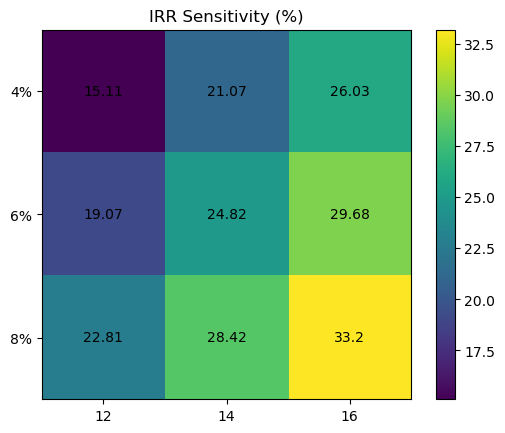

Saved successfully to Downloads ✅


In [18]:
import matplotlib.pyplot as plt

# 📊 Heatmap
plt.figure()
plt.imshow(pivot)

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        plt.text(j, i, pivot.iloc[i, j], ha='center', va='center')

plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), [f"{int(g*100)}%" for g in pivot.index])

plt.title("IRR Sensitivity (%)")
plt.colorbar()

# 🔥 Save directly to your Downloads
plt.savefig("/Users/nishantpandya/Downloads/heatmap.png", dpi=300, bbox_inches='tight')

plt.show()

print("Saved successfully to Downloads ✅")

In [13]:
results = []

for g in [0.04,0.06,0.08]:
    for m in [12,14,16]:

        rev = revenue
        debt_temp = senior_debt + mezz_debt

        for _ in range(holding_period):
            rev *= (1+g)
            ebitda = rev * ebitda_margin
            debt_temp -= max(ebitda*0.3,0)

        exit_val = ebitda * m
        eq_val = exit_val - debt_temp
        irr_val = (eq_val/equity)**(1/holding_period)-1

        results.append({"Growth":g,"Multiple":m,"IRR":round(irr_val*100,2)})

sens_df = pd.DataFrame(results)
sens_df

,Growth,Multiple,IRR
0,0.04,12,15.11
1,0.04,14,21.07
2,0.04,16,26.03
3,0.06,12,19.07
4,0.06,14,24.82
5,0.06,16,29.68
6,0.08,12,22.81
7,0.08,14,28.42
8,0.08,16,33.20


In [14]:
low = sens_df[sens_df["IRR"] < 20]

print("Sensitivity Insight:")
print(low if not low.empty else "All IRRs > 20%")

Sensitivity Insight:
   Growth  Multiple    IRR
0    0.04        12  15.11
3    0.06        12  19.07


In [18]:
print("Total Sources:", round(senior_debt + mezz_debt + equity,2))
print("Total Uses:", round(purchase_price + fees,2))

Total Sources: 1498.18
Total Uses: 1528.14


In [16]:
## Investment Memo

### Deal Overview
##Acquisition of Apple at ~12x EBITDA with leveraged capital structure.

### Investment Thesis
##Strong and stable EBITDA margins (~30%)
##High free cash flow generation enabling deleveraging
##Premium valuation justified by brand strength and ecosystem

### Value Creation Drivers
##EBITDA growth
##Debt paydown
##Multiple expansion

### Key Risks
##Exit multiple compression
##Growth slowdown
##Interest rate increase

In [20]:
initial_value = purchase_price
final_value = exit_value

growth_value = final_ebitda * entry_multiple
multiple_expansion = exit_value - growth_value

debt_reduction = (senior_debt + mezz_debt) - remaining_debt

print("---- VALUE CREATION ----")
print("From EBITDA Growth:", round(growth_value - initial_value,2))
print("From Multiple Expansion:", round(multiple_expansion,2))
print("From Debt Reduction:", round(debt_reduction,2))

---- VALUE CREATION ----
From EBITDA Growth: 506.78
From Multiple Expansion: 334.16
From Debt Reduction: 173.86


In [17]:
print("----- FINAL -----")
print("Equity Invested:", round(equity,2))
print("Equity Exit:", round(equity_exit,2))
print("IRR:", round(irr*100,2), "%")
print("MOIC:", round(moic,2))

----- FINAL -----
Equity Invested: 524.36
Equity Exit: 1539.16
IRR: 24.03 %
MOIC: 2.94
